# ⚽ K-Means Clustering — Style Scoring Approach

---

## Overview

### Tujuan
Notebook ini mengelompokkan **20 klub La Liga** berdasarkan **10 Style Scores** menggunakan **K-Means Clustering**. Berbeda dengan clustering langsung pada raw features, notebook ini terlebih dahulu melakukan **feature engineering** untuk membentuk scoring yang merepresentasikan dimensi gaya bermain.

### Pipeline

```
Raw Statistical Features (124 kolom)
        ↓
Feature Engineering (STYLE_CONFIG)
        ↓
10 Style Scores
        ↓
StandardScaler
        ↓
K-Means Clustering
        ↓
Cluster Assignment + Profiling + Interpretasi
```

### 10 Style Scores

| # | Style Score | Mengukur |
|---|-------------|----------|
| 1 | Possession Score | Dominasi penguasaan bola |
| 2 | Build-up Score | Kecenderungan membangun serangan secara sabar |
| 3 | Chance Creation Score | Kemampuan menciptakan peluang |
| 4 | Attacking Efficiency Score | Efisiensi mengubah peluang menjadi gol |
| 5 | Direct Play Score | Kecenderungan permainan langsung dan vertikal |
| 6 | Counter Attack Score | Kemampuan serangan balik cepat |
| 7 | Pressing Score | Intensitas pressing dan tekanan tinggi |
| 8 | Defensive Solidity Score | Kekuatan dan kesolidan pertahanan |
| 9 | Set Piece Score | Ancaman dari situasi bola mati |
| 10 | Discipline Score | Disiplin dan minimnya kesalahan |

### Mengapa K-Means?
- Memberikan **hard assignment** — setiap klub masuk tepat satu cluster.
- Cocok untuk 10 feature dengan 20 observation.
- Menghasilkan centroid yang mudah diinterpretasikan sebagai "profil rata-rata" cluster.

---

## 0. Import Library

In [34]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.decomposition import PCA

# Settings
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

print("✅ Library berhasil diimpor.")

✅ Library berhasil diimpor.


---

## 1. Load Dataset

Dataset yang dimuat adalah **`teams_statistics.csv`** — One Big Table (OBT) dari Gold Layer yang berisi 124 kolom statistik per klub. File ini digunakan karena proses Style Scoring membutuhkan feature yang lebih lengkap dibandingkan `teams_ml_features.csv` (52 kolom subset).

Setiap baris merepresentasikan satu klub La Liga. Kolom statistik merupakan **feature dasar** yang nantinya digunakan untuk membentuk **Style Scores** — bukan langsung sebagai input K-Means.

In [35]:
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "gold" / "teams" / "teams_statistics.csv"

df = pd.read_csv(data_path)

print(f"✅ Dataset dimuat: {data_path.name}")
print(f"   Shape : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"   Klub  : {df.shape[0]}")

✅ Dataset dimuat: teams_statistics.csv
   Shape : 20 baris × 124 kolom
   Klub  : 20


In [36]:
df.head()

,club,played,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_np_shots,att_np_sot,att_np_conv_pct,att_np_xg_per_shot,att_sp_goals,att_sp_shots,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_sp_xg_pct,att_touches_in_box,att_hit_woodwork,att_offsides,att_penalties_total,att_penalties_goals,att_free_kicks_total,att_free_kicks_goals,att_headers_total,att_headers_goals,att_fast_breaks_total,att_fast_breaks_goals,def_avg_possession_pct,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_ground_duels_won_pct,def_aerial_duels_won_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_sot_against,def_conv_pct_against,def_xg_per_shot_against,def_shots_in_box_pct,def_goals_in_box_pct,def_sp_goals,def_sp_shots,def_sp_xg,def_sp_goal_pct,def_sp_shot_pct,def_sp_xg_pct,def_touches_in_box,def_hit_woodwork,def_offsides,def_penalties_total,def_penalties_goals,def_free_kicks_total,def_free_kicks_goals,def_headers_total,def_headers_goals,def_fast_breaks_total,def_fast_breaks_goals,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_total,pas_final_third_successful,pas_final_third_pct,pas_direction_fwd_pct,pas_direction_bwd_pct,pas_direction_left_pct,pas_direction_right_pct,pas_crosses_total,pas_crosses_successful,pas_crosses_pct,pas_through_balls,prs_pressed_seqs,prs_ppda,prs_start_distance,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_passes_10_plus,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_buildups_goals,seq_direct_attacks_total,seq_direct_attacks_goals,msc_subs_used,msc_subs_goals,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_fouled,msc_yellows,msc_reds,msc_pens_won,msc_fouls,msc_opp_yellows,msc_opp_reds,msc_pens_conceded,att_goals_per_game,att_shots_per_game,att_xg_per_game,att_fast_breaks_per_game,att_touches_in_box_per_game,def_tackles_per_game,def_interceptions_per_game,def_goals_conceded_per_game,pas_passes_per_game,pas_crosses_per_game,pas_through_balls_per_game,prs_pressed_seqs_per_game,seq_buildups_per_game,seq_direct_attacks_per_game,msc_fouls_per_game,msc_yellows_per_game
0,Alaves,38,44,47.05,-3.05,463,153,9.50,0.10,37,41.54,-4.54,456,146,8.11,0.09,11,135,11.00,25.00,29.16,23.37,778,12,74,7,7,10,1,82,6,29,1,48.00,691,297,1859,148,901,47.50,49.40,56,47.67,8.33,473,154,11.84,0.10,64.69,87.50,6,154,12.54,10.71,32.56,26.31,854,10,55,5,5,13,0,94,7,30,8,15362,12346,80.40,4305,2915,67.70,34.80,15.90,24.60,24.80,538,117,21.80,32,416,11.50,41.40,233,44,4,18.88,299,1.81,3.14,8.01,56,2,47,1,172,6,19,4,489,86,5,7,539,75,6,5,1.16,12.18,1.24,0.76,20.47,18.18,7.82,1.47,404.26,14.16,0.84,10.95,1.47,1.24,14.18,2.26
1,Athletic Bilbao,38,43,50.60,-7.60,522,172,8.24,0.10,38,45.87,-7.87,516,166,7.36,0.09,6,139,10.55,13.95,26.63,20.85,978,12,52,6,5,20,0,95,5,18,4,48.60,571,349,1983,78,808,45.50,49.60,58,42.24,15.76,357,161,16.25,0.12,64.43,79.31,9,88,5.53,15.52,24.65,13.08,610,4,127,6,3,7,2,50,5,38,7,15562,12496,80.30,5114,3421,66.90,35.00,14.60,25.50,25.00,698,137,19.60,59,557,11.20,45.00,368,61,3,16.58,276,2.03,3.08,8.12,57,2,42,5,189,8,27,6,391,73,7,6,497,75,4,6,1.13,13.74,1.33,0.47,25.74,15.03,9.18,1.53,409.53,18.37,1.55,14.66,1.50,1.11,13.08,1.92
2,Atlético Madrid,38,62,58.87,3.13,498,193,12.45,0.12,59,55.71,3.29,494,189,11.94,0.11,12,132,11.00,19.35,26.51,18.68,1060,15,79,4,3,10,2,105,12,33,8,53.30,647,297,1839,114,812,48.60,53.80,44,48.98,-4.98,441,142,9.98,0.11,61.45,81.82,9,133,11.22,20.45,30.16,22.90,752,9,59,6,5,15,0,82,7,27,7,19208,16443,85.60,5438,4121,75.80,30.20,15.70,27.10,27.00,561,130,23.20,100,427,12.20,42.30,267,31,5,11.61,495,1.70,4.16,11.03,124,6,64,2,184,18,22,4,345,77,5,4,399,75,2,6,1.63,13.11,1.55,0.87,27.89,17.03,7.82,1.16,505.47,14.76,2.63,11.24,3.26,1.68,10.50,2.03
3,Barcelona,38,95,86.62,8.38,692,257,13.73,0.13,88,78.73,9.27,682,250,12.90,0.12,15,155,11.48,15.79,

In [37]:
# --- Seluruh kolom ---
print(f"Seluruh kolom ({len(df.columns)}):\n")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:>3d}. {col}")

Seluruh kolom (124):

     1. club
     2. played
     3. att_goals
     4. att_xg
     5. att_goals_vs_xg
     6. att_shots
     7. att_sot
     8. att_conversion_pct
     9. att_xg_per_shot
    10. att_np_goals
    11. att_np_xg
    12. att_np_goals_vs_xg
    13. att_np_shots
    14. att_np_sot
    15. att_np_conv_pct
    16. att_np_xg_per_shot
    17. att_sp_goals
    18. att_sp_shots
    19. att_sp_xg
    20. att_sp_goal_pct
    21. att_sp_shot_pct
    22. att_sp_xg_pct
    23. att_touches_in_box
    24. att_hit_woodwork
    25. att_offsides
    26. att_penalties_total
    27. att_penalties_goals
    28. att_free_kicks_total
    29. att_free_kicks_goals
    30. att_headers_total
    31. att_headers_goals
    32. att_fast_breaks_total
    33. att_fast_breaks_goals
    34. def_avg_possession_pct
    35. def_tackles
    36. def_interceptions
    37. def_possession_won
    38. def_blocks
    39. def_clearances
    40. def_ground_duels_won_pct
    41. def_aerial_duels_won_pct
    42. de

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Columns: 124 entries, club to msc_yellows_per_game
dtypes: float64(54), int64(69), str(1)
memory usage: 19.7 KB


In [39]:
# --- Missing values ---
missing = df.isnull().sum()
print(f"Missing values total: {missing.sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✅ Tidak ada missing values.")

print(f"\nJumlah klub: {df['club'].nunique()}")
assert "club" in df.columns, "Kolom 'club' tidak ditemukan!"

Missing values total: 0
✅ Tidak ada missing values.

Jumlah klub: 20


### Interpretasi

Dataset Gold Layer berisi **124 kolom statistik** untuk **20 klub** La Liga. Data sudah bersih tanpa missing values. Kolom-kolom ini mencakup attacking, defending, passing, pressing, sequences, dan discipline — yang akan diagregasi menjadi 10 Style Scores.

---

## 2. Definisikan STYLE_CONFIG

Setiap Style Score dibangun dari:
- **Primary indicators** (bobot 60%) — indikator utama yang paling merepresentasikan dimensi gaya bermain.
- **Supporting indicators** (bobot 40%) — indikator pendukung yang memperkaya penilaian.
- **Inverse indicators** — indikator yang arah nilainya perlu dibalik (misal: PPDA rendah = pressing tinggi).

In [40]:
STYLE_CONFIG = {

    # ----- 1. Possession Score -----
    "possession": {
        "primary": [
            "def_avg_possession_pct",
            "pas_passes_total",
            "pas_passes_successful",
            "pas_passes_pct",
        ],
        "supporting": [
            "pas_final_third_pct",
            "seq_passes_per_seq",
            "seq_sequence_time",
        ],
        "inverse": [],
    },

    # ----- 2. Build-up Score -----
    "build_up": {
        "primary": [
            "seq_buildups_total",
            "seq_passes_per_seq",
            "seq_sequence_time",
        ],
        "supporting": [
            "pas_passes_total",
            "pas_passes_pct",
            "pas_final_third_successful",
        ],
        "inverse": [],
    },

    # ----- 3. Chance Creation Score -----
    "chance_creation": {
        "primary": [
            "att_touches_in_box",
            "pas_through_balls",
            "pas_final_third_successful",
            "att_shots",
        ],
        "supporting": [
            "pas_crosses_successful",
            "att_xg",
            "att_sot",
        ],
        "inverse": [],
    },

    # ----- 4. Attacking Efficiency Score -----
    "attacking_efficiency": {
        "primary": [
            "att_goals",
            "att_xg",
            "att_goals_vs_xg",
            "att_conversion_pct",
        ],
        "supporting": [
            "att_xg_per_shot",
            "att_sot",
            "att_goals_per_game",
        ],
        "inverse": [],
    },

    # ----- 5. Direct Play Score -----
    "direct_play": {
        "primary": [
            "seq_direct_speed",
            "seq_direct_attacks_total",
            "pas_direction_fwd_pct",
        ],
        "supporting": [
            "pas_through_balls",
            "att_fast_breaks_total",
            "seq_passes_per_seq",
        ],
        "inverse": ["seq_passes_per_seq"],
    },

    # ----- 6. Counter Attack Score -----
    "counter_attack": {
        "primary": [
            "seq_direct_attacks_total",
            "seq_direct_attacks_goals",
            "att_fast_breaks_total",
        ],
        "supporting": [
            "att_fast_breaks_goals",
            "seq_direct_speed",
            "seq_sequence_time",
        ],
        "inverse": ["seq_sequence_time"],
    },

    # ----- 7. Pressing Intensity Score -----
    "pressing": {
        "primary": [
            "prs_ppda",
            "prs_pressed_seqs",
            "prs_high_turnovers_total",
        ],
        "supporting": [
            "prs_high_turnovers_shot_ending",
            "prs_high_turnovers_goal_ending",
            "prs_high_turnovers_shot_pct",
        ],
        "inverse": ["prs_ppda"],
    },

    # ----- 8. Defensive Solidity Score -----
    "defensive_solidity": {
        "primary": [
            "def_goals_conceded",
            "def_xg_against",
            "def_shots_against",
            "def_shots_in_box_pct",
        ],
        "supporting": [
            "def_tackles",
            "def_interceptions",
            "def_blocks",
            "def_clearances",
            "def_goals_vs_xg_against",
        ],
        "inverse": [
            "def_goals_conceded",
            "def_xg_against",
            "def_shots_against",
            "def_shots_in_box_pct",
        ],
    },

    # ----- 9. Set Piece Threat Score -----
    "set_piece": {
        "primary": [
            "att_sp_goals",
            "att_sp_xg",
        ],
        "supporting": [
            "att_sp_shots",
            "att_sp_goal_pct",
            "att_sp_shot_pct",
            "att_sp_xg_pct",
        ],
        "inverse": [],
    },

    # ----- 10. Discipline Score -----
    "discipline": {
        "primary": [
            "msc_fouls",
            "msc_yellows",
            "msc_reds",
            "msc_errors_lead_to_goal",
        ],
        "supporting": [
            "msc_errors_lead_to_shot",
            "msc_pens_conceded",
        ],
        "inverse": [
            "msc_fouls",
            "msc_yellows",
            "msc_reds",
            "msc_errors_lead_to_goal",
            "msc_errors_lead_to_shot",
            "msc_pens_conceded",
        ],
    },
}

print(f"✅ STYLE_CONFIG terdefinisi: {len(STYLE_CONFIG)} scoring")
for name, cfg in STYLE_CONFIG.items():
    n_p = len(cfg['primary'])
    n_s = len(cfg['supporting'])
    n_i = len(cfg['inverse'])
    print(f"   {name:<25s}  primary={n_p}  supporting={n_s}  inverse={n_i}")

✅ STYLE_CONFIG terdefinisi: 10 scoring
   possession                 primary=4  supporting=3  inverse=0
   build_up                   primary=3  supporting=3  inverse=0
   chance_creation            primary=4  supporting=3  inverse=0
   attacking_efficiency       primary=4  supporting=3  inverse=0
   direct_play                primary=3  supporting=3  inverse=1
   counter_attack             primary=3  supporting=3  inverse=1
   pressing                   primary=3  supporting=3  inverse=1
   defensive_solidity         primary=4  supporting=5  inverse=4
   set_piece                  primary=2  supporting=4  inverse=0
   discipline                 primary=4  supporting=2  inverse=6


### Validasi Ketersediaan Feature

Sebelum menghitung Style Scores, pastikan seluruh feature yang dibutuhkan STYLE_CONFIG tersedia dalam dataset.

In [41]:
# --- Validasi ketersediaan seluruh feature ---
all_features_needed = set()
for cfg in STYLE_CONFIG.values():
    all_features_needed.update(cfg["primary"])
    all_features_needed.update(cfg["supporting"])

available = set(df.columns)
missing_features = all_features_needed - available

print(f"Feature dibutuhkan : {len(all_features_needed)}")
print(f"Feature tersedia   : {len(all_features_needed - missing_features)}")
print(f"Feature tidak ada  : {len(missing_features)}")

if missing_features:
    print(f"\n⚠️  Missing: {sorted(missing_features)}")
else:
    print("\n✅ Seluruh feature tersedia dalam dataset.")

Feature dibutuhkan : 53
Feature tersedia   : 53
Feature tidak ada  : 0

✅ Seluruh feature tersedia dalam dataset.


---

## 3. Feature Engineering — Membentuk Style Scores

### Proses Perhitungan

Untuk setiap Style Score, langkah-langkahnya:

1. **Ambil** seluruh primary dan supporting indicators.
2. **Normalisasi** setiap indikator ke rentang 0–1 menggunakan Min-Max scaling.
3. **Inverse** — untuk indikator yang tercantum pada `inverse`, balik nilainya: `1 - normalized_value`. Ini memastikan bahwa nilai tinggi selalu berarti "karakteristik lebih kuat" (misal: PPDA rendah → pressing tinggi → setelah inverse nilainya tinggi).
4. **Agregasi** — hitung rata-rata primary indicators dan rata-rata supporting indicators.
5. **Bobot** — gabungkan dengan bobot **Primary 60% + Supporting 40%**.
6. **Skalakan** ke rentang 0–100.

```
Primary Score   = mean(normalized primary indicators)   × 0.60
Supporting Score = mean(normalized supporting indicators) × 0.40
Style Score      = (Primary Score + Supporting Score) × 100
```

In [42]:
def compute_style_score(df, config, score_name):
    """
    Menghitung Style Score berdasarkan konfigurasi.

    Parameters:
        df      : DataFrame dengan seluruh feature
        config  : dict dengan keys 'primary', 'supporting', 'inverse'
        score_name : nama scoring (untuk logging)

    Returns:
        Series dengan nilai 0-100
    """
    primary_cols    = [c for c in config["primary"]    if c in df.columns]
    supporting_cols = [c for c in config["supporting"] if c in df.columns]
    inverse_cols    = set(config["inverse"])

    def normalize_and_invert(cols):
        """Min-Max normalize, lalu inverse jika diperlukan."""
        normalized = pd.DataFrame(index=df.index)
        for col in cols:
            mn = df[col].min()
            mx = df[col].max()
            if mx == mn:
                normalized[col] = 0.5
            else:
                norm_val = (df[col] - mn) / (mx - mn)
                if col in inverse_cols:
                    norm_val = 1 - norm_val
                normalized[col] = norm_val
        return normalized

    # Normalize primary dan supporting
    primary_norm   = normalize_and_invert(primary_cols)
    supporting_norm = normalize_and_invert(supporting_cols)

    # Mean per kelompok
    primary_score   = primary_norm.mean(axis=1)   if len(primary_cols) > 0   else 0
    supporting_score = supporting_norm.mean(axis=1) if len(supporting_cols) > 0 else 0

    # Weighted aggregation
    W_PRIMARY = 0.60
    W_SUPPORTING = 0.40

    final_score = (W_PRIMARY * primary_score + W_SUPPORTING * supporting_score) * 100

    return final_score


print("✅ Fungsi compute_style_score() siap.")

✅ Fungsi compute_style_score() siap.


In [43]:
# --- Hitung seluruh 10 Style Scores ---
SCORE_NAMES = {
    "possession":           "possession_score",
    "build_up":             "build_up_score",
    "chance_creation":      "chance_creation_score",
    "attacking_efficiency": "attacking_efficiency_score",
    "direct_play":          "direct_play_score",
    "counter_attack":       "counter_attack_score",
    "pressing":             "pressing_score",
    "defensive_solidity":   "defensive_solidity_score",
    "set_piece":            "set_piece_score",
    "discipline":           "discipline_score",
}

df_scores = df[["club"]].copy()

for config_key, score_col in SCORE_NAMES.items():
    df_scores[score_col] = compute_style_score(
        df, STYLE_CONFIG[config_key], config_key
    )
    print(f"   ✅ {score_col:<35s}  "
          f"min={df_scores[score_col].min():.1f}  "
          f"max={df_scores[score_col].max():.1f}  "
          f"mean={df_scores[score_col].mean():.1f}")

print(f"\n✅ Seluruh 10 Style Scores berhasil dihitung.")
print(f"   Shape: {df_scores.shape}")

   ✅ possession_score                     min=0.0  max=99.8  mean=47.0
   ✅ build_up_score                       min=0.0  max=100.0  mean=42.8
   ✅ chance_creation_score                min=5.8  max=91.1  mean=38.5
   ✅ attacking_efficiency_score           min=7.4  max=93.7  mean=40.7
   ✅ direct_play_score                    min=27.8  max=63.8  mean=43.7
   ✅ counter_attack_score                 min=21.9  max=83.0  mean=39.9
   ✅ pressing_score                       min=9.2  max=73.2  mean=38.2
   ✅ defensive_solidity_score             min=36.4  max=73.4  mean=52.5
   ✅ set_piece_score                      min=8.2  max=88.1  mean=45.0
   ✅ discipline_score                     min=22.8  max=89.5  mean=56.2

✅ Seluruh 10 Style Scores berhasil dihitung.
   Shape: (20, 11)


### Interpretasi

Setiap Style Score memiliki:
- **0** = karakteristik paling rendah di liga.
- **100** = karakteristik paling tinggi di liga.

Inverse indicators sudah dibalik sehingga nilai tinggi selalu berarti "karakteristik lebih kuat". Misalnya, Discipline Score tinggi berarti klub **lebih disiplin** (sedikit foul, kartu, dan error).

---

## 4. Penanganan Inverse Indicators

Beberapa indikator memiliki interpretasi **terbalik** — semakin kecil nilainya, semakin kuat karakteristik yang diukur:

| Indikator | Logika Inverse |
|-----------|----------------|
| `prs_ppda` | PPDA rendah → pressing lebih intens |
| `def_goals_conceded` | Kebobolan sedikit → pertahanan solid |
| `def_xg_against` | xG against rendah → pertahanan solid |
| `def_shots_against` | Tembakan lawan sedikit → pertahanan solid |
| `def_shots_in_box_pct` | Tembakan lawan dari dalam kotak rendah → pertahanan solid |
| `seq_passes_per_seq` | Passes per sequence sedikit → permainan lebih direct |
| `seq_sequence_time` | Waktu sequence pendek → counter attack cepat |
| `msc_fouls`, `msc_yellows`, `msc_reds` | Sedikit pelanggaran → lebih disiplin |
| `msc_errors_lead_to_*`, `msc_pens_conceded` | Sedikit error → lebih disiplin |

Pendekatan yang digunakan: **Min-Max Inversion**

```
inverse_value = 1 - normalized_value
```

Setelah inversion, seluruh Style Scores memiliki interpretasi yang konsisten: **semakin tinggi = semakin kuat.**

---

## 5. Validasi Style Scores

Sebelum menggunakan Style Scores sebagai input K-Means, pastikan hasilnya valid.

In [44]:
# --- Tampilkan seluruh scoring ---
score_cols = list(SCORE_NAMES.values())

df_scores.sort_values("club").reset_index(drop=True)

,club,possession_score,build_up_score,chance_creation_score,attacking_efficiency_score,direct_play_score,counter_attack_score,pressing_score,defensive_solidity_score,set_piece_score,discipline_score
0,Alaves,36.07,30.53,30.49,29.19,38.65,27.11,42.75,58.82,55.21,61.87
1,Athletic Bilbao,36.19,32.40,48.81,26.54,47.68,38.08,73.22,61.00,34.02,54.28
2,Atlético Madrid,64.13,61.77,61.09,58.54,38.98,33.93,35.33,58.04,51.70,70.46
3,Barcelona,99.80,100.00,91.06,93.75,32.82,45.88,72.06,50.73,57.58,89.50
4,Celta Vigo,64.03,62.05,34.87,54.75,31.21,23.52,22.05,47.38,8.21,48.11
5,Elche,63.64,54.86,31.56,39.11,27.77,30.88,45.09,38.68,10.18,47.61
6,Espanyol,22.15,20.89,31.53,27.07,57.27,41.80,36.85,44.60,87.36,66.39
7,Getafe,0.00,0.00,5.79,14.26,47.46,22.48,33.31,73.37,66.52,45.42
8,Girona,59.66,54.86,30.88,26.94,30.45,26.44,14.34,37.45,21.89,55.24
9,Levante,24.73,22.52,33.25,33.77,51.66,47.15,33.14,38.26,88.06,74.70


In [45]:
# --- Validasi ---
print("📊 Validasi Style Scores:\n")

# 1. Missing values
ms = df_scores[score_cols].isnull().sum().sum()
print(f"1️⃣  Missing values  : {ms} {'✅' if ms == 0 else '❌'}")

# 2. Infinite values
inf = np.isinf(df_scores[score_cols]).sum().sum()
print(f"2️⃣  Infinite values : {inf} {'✅' if inf == 0 else '❌'}")

# 3. Rentang 0-100
min_val = df_scores[score_cols].min().min()
max_val = df_scores[score_cols].max().max()
in_range = min_val >= 0 and max_val <= 100
print(f"3️⃣  Rentang 0–100   : [{min_val:.1f}, {max_val:.1f}] {'✅' if in_range else '❌'}")

# 4. Satu baris = satu klub
unique_clubs = df_scores["club"].nunique() == df_scores.shape[0]
print(f"4️⃣  Satu baris/klub : {df_scores.shape[0]} baris, {df_scores['club'].nunique()} klub {'✅' if unique_clubs else '❌'}")

📊 Validasi Style Scores:

1️⃣  Missing values  : 0 ✅
2️⃣  Infinite values : 0 ✅
3️⃣  Rentang 0–100   : [0.0, 100.0] ✅
4️⃣  Satu baris/klub : 20 baris, 20 klub ✅


In [46]:
# --- Statistik deskriptif ---
df_scores[score_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
possession_score,20.00,46.97,22.41,0.00,36.16,41.51,60.66,99.80
build_up_score,20.00,42.81,22.93,0.00,31.00,34.58,54.86,100.00
chance_creation_score,20.00,38.50,19.77,5.79,30.24,33.50,40.70,91.06
attacking_efficiency_score,20.00,40.71,21.63,7.37,27.03,33.10,54.96,93.75
direct_play_score,20.00,43.74,10.38,27.77,37.19,45.45,48.76,63.81
counter_attack_score,20.00,39.86,15.30,21.94,29.94,39.49,42.82,82.96
pressing_score,20.00,38.19,18.54,9.16,25.08,36.09,46.18,73.22
defensive_solidity_score,20.00,52.47,11.17,36.38,44.27,52.36,60.53,73.37
set_piece_score,20.00,44.96,24.94,8.21,25.48,47.48,59.81,88.06
discipline_score,20.00,56.21,16.29,22.75,47.48,54.76,67.41,89.50


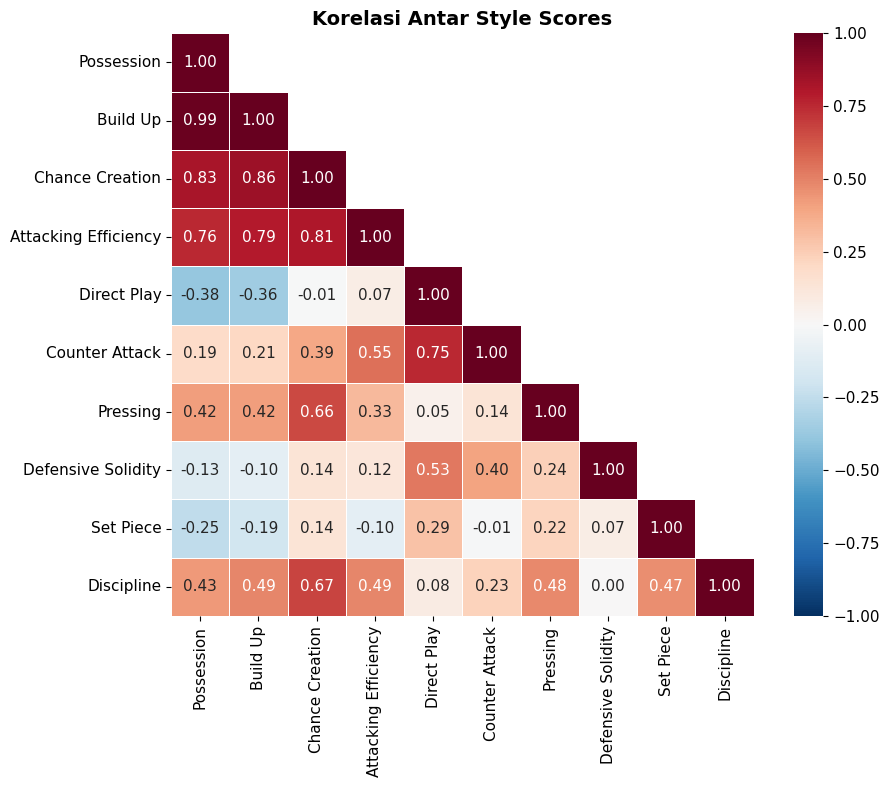

In [47]:
# --- Heatmap korelasi ---
corr = df_scores[score_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    xticklabels=[c.replace("_score", "").replace("_", " ").title() for c in score_cols],
    yticklabels=[c.replace("_score", "").replace("_", " ").title() for c in score_cols],
)
ax.set_title("Korelasi Antar Style Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretasi

Heatmap korelasi menunjukkan hubungan antar dimensi gaya bermain. Korelasi positif yang kuat (misalnya Possession dan Build-up) menunjukkan bahwa dimensi tersebut cenderung muncul bersamaan. Korelasi negatif menunjukkan karakteristik yang berlawanan.

**Catatan:** Tujuan heatmap bukan untuk menghapus feature, melainkan **memahami** relasi antar dimensi. Seluruh 10 scoring tetap digunakan sebagai input K-Means.

---

## 6. Dataset untuk Machine Learning

Feature yang masuk ke K-Means adalah **10 Style Scores**, bukan 124 kolom statistik mentah.

```
Raw statistical features (124 kolom)
        ↓
Feature Engineering (STYLE_CONFIG)
        ↓
10 Style Scores ← CLUSTER_FEATURES
        ↓
K-Means
```

Kolom `club` hanya digunakan sebagai identifier dan **tidak** masuk ke model.

In [48]:
CLUSTER_FEATURES = [
    "possession_score",
    "build_up_score",
    "chance_creation_score",
    "attacking_efficiency_score",
    "direct_play_score",
    "counter_attack_score",
    "pressing_score",
    "defensive_solidity_score",
    "set_piece_score",
    "discipline_score",
]

X = df_scores[CLUSTER_FEATURES].copy()
clubs = df_scores["club"].copy()

print(f"✅ Dataset untuk K-Means:")
print(f"   X.shape : {X.shape}  ({X.shape[0]} klub × {X.shape[1]} style scores)")
print(f"   Identifier: club")
print(f"   Features:")
for i, col in enumerate(CLUSTER_FEATURES, 1):
    print(f"     {i:>2d}. {col}")

✅ Dataset untuk K-Means:
   X.shape : (20, 10)  (20 klub × 10 style scores)
   Identifier: club
   Features:
      1. possession_score
      2. build_up_score
      3. chance_creation_score
      4. attacking_efficiency_score
      5. direct_play_score
      6. counter_attack_score
      7. pressing_score
      8. defensive_solidity_score
      9. set_piece_score
     10. discipline_score


---

## 7. Scaling Sebelum K-Means

### Dua Tahap Normalisasi yang Berbeda

| Tahap | Tujuan | Kapan |
|-------|--------|-------|
| **Scoring Normalization** (Min-Max) | Menyamakan skala antar-indikator **di dalam** satu scoring | Saat membentuk Style Scores |
| **K-Means Standardization** (StandardScaler) | Menyamakan kontribusi antar-scoring **terhadap distance** | Sebelum training K-Means |

### Mengapa perlu StandardScaler lagi?

Meskipun seluruh Style Scores sudah berada pada rentang 0–100, **distribusi dan variasi** setiap scoring bisa berbeda. Scoring dengan standar deviasi besar akan berkontribusi lebih besar terhadap Euclidean distance. StandardScaler memastikan setiap scoring memiliki **mean ≈ 0** dan **std ≈ 1** sehingga kontribusinya setara.

In [49]:
# --- Variasi sebelum scaling ---
print("📊 Variasi Style Scores SEBELUM scaling:\n")
for col in CLUSTER_FEATURES:
    print(f"   {col:<35s}  std = {X[col].std():>5.2f}  range = [{X[col].min():.1f}, {X[col].max():.1f}]")

📊 Variasi Style Scores SEBELUM scaling:

   possession_score                     std = 22.41  range = [0.0, 99.8]
   build_up_score                       std = 22.93  range = [0.0, 100.0]
   chance_creation_score                std = 19.77  range = [5.8, 91.1]
   attacking_efficiency_score           std = 21.63  range = [7.4, 93.7]
   direct_play_score                    std = 10.38  range = [27.8, 63.8]
   counter_attack_score                 std = 15.30  range = [21.9, 83.0]
   pressing_score                       std = 18.54  range = [9.2, 73.2]
   defensive_solidity_score             std = 11.17  range = [36.4, 73.4]
   set_piece_score                      std = 24.94  range = [8.2, 88.1]
   discipline_score                     std = 16.29  range = [22.8, 89.5]


In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=X.index)

print("📊 SESUDAH StandardScaler:\n")
for col in CLUSTER_FEATURES:
    col_idx = CLUSTER_FEATURES.index(col)
    print(f"   {col:<35s}  mean = {X_scaled[:, col_idx].mean():>7.4f}   std = {X_scaled[:, col_idx].std():>6.4f}")

print(f"\n✅ Seluruh scoring: mean ≈ 0, std ≈ 1")

📊 SESUDAH StandardScaler:

   possession_score                     mean =  0.0000   std = 1.0000
   build_up_score                       mean =  0.0000   std = 1.0000
   chance_creation_score                mean =  0.0000   std = 1.0000
   attacking_efficiency_score           mean = -0.0000   std = 1.0000
   direct_play_score                    mean = -0.0000   std = 1.0000
   counter_attack_score                 mean = -0.0000   std = 1.0000
   pressing_score                       mean = -0.0000   std = 1.0000
   defensive_solidity_score             mean = -0.0000   std = 1.0000
   set_piece_score                      mean = -0.0000   std = 1.0000
   discipline_score                     mean =  0.0000   std = 1.0000

✅ Seluruh scoring: mean ≈ 0, std ≈ 1


### Interpretasi

Sebelum scaling, beberapa scoring memiliki standar deviasi yang lebih besar (variasi lebih lebar). Setelah StandardScaler, seluruh scoring berkontribusi secara proporsional terhadap Euclidean distance dalam K-Means.

---

## 8. Menentukan Jumlah Cluster (K)

Jumlah cluster ditentukan berdasarkan evaluasi beberapa metrik:

| Metrik | Arti | Ideal |
|--------|------|-------|
| **Inertia** | Total jarak kuadrat ke centroid | Semakin kecil (cari elbow) |
| **Silhouette** | Kecocokan dalam cluster vs cluster lain | Mendekati +1 |
| **Davies-Bouldin** | Rasio dispersi vs separasi | Semakin kecil |
| **Calinski-Harabasz** | Rasio between-cluster vs within-cluster variance | Semakin besar |

In [51]:
K_RANGE = range(2, 7)  # K = 2 sampai 6

results = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    results.append({
        "K": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels),
    })

eval_df = pd.DataFrame(results)
print("📊 Evaluasi Jumlah Cluster:\n")
print(eval_df.to_string(index=False))

📊 Evaluasi Jumlah Cluster:

 K  Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2   140.47        0.40            0.67               7.63
 3   103.43        0.24            1.19               7.94
 4    77.42        0.27            1.05               8.44
 5    62.14        0.23            1.10               8.32
 6    55.59        0.24            0.81               7.27


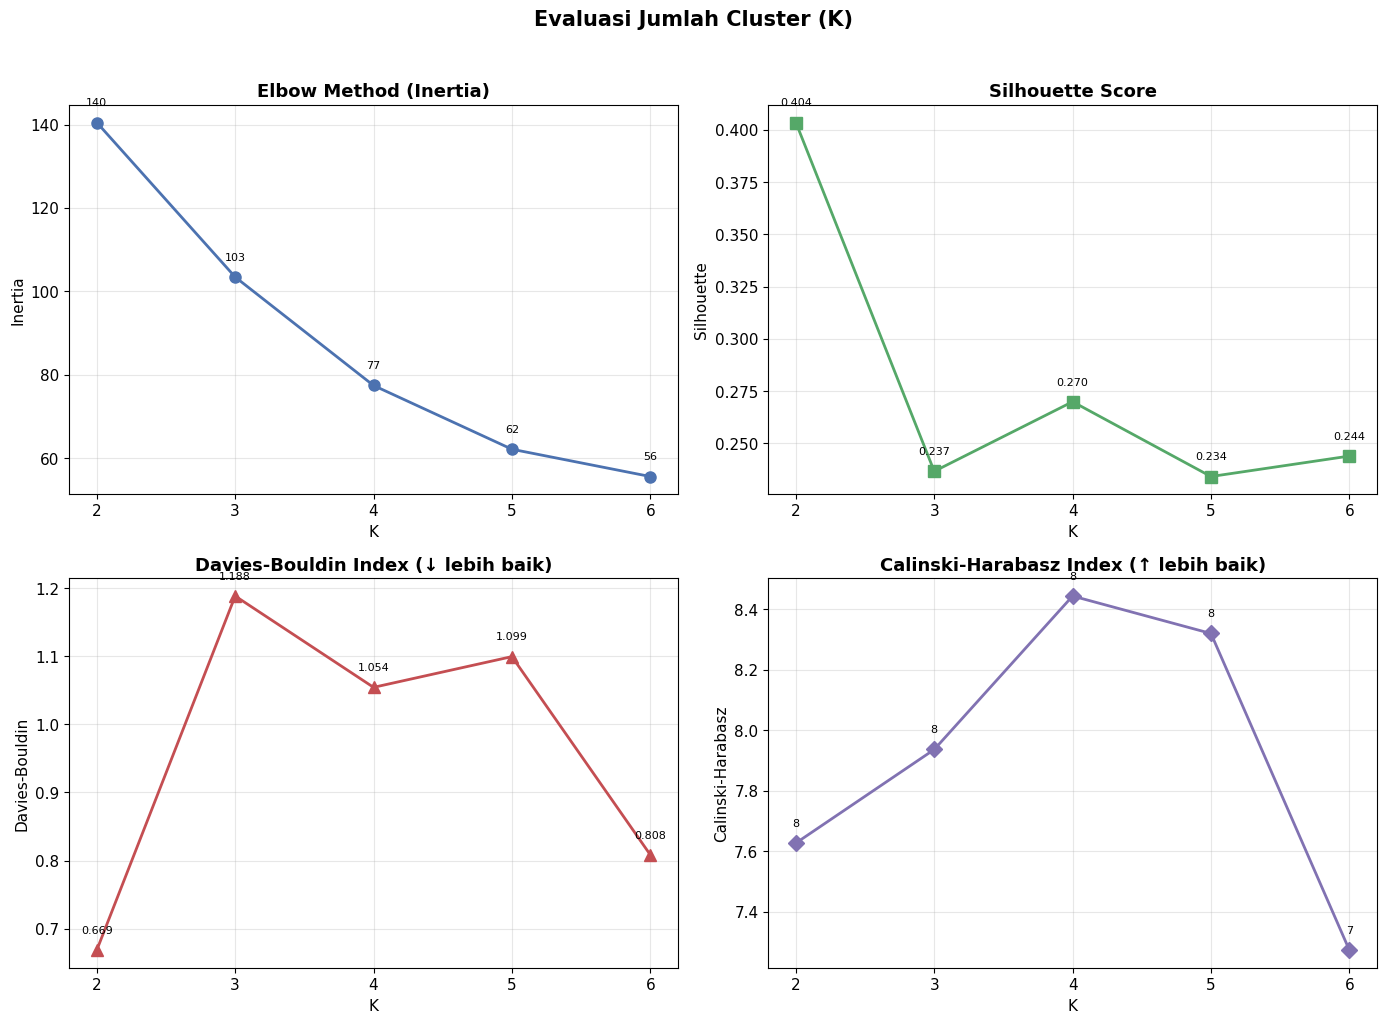

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Elbow ---
axes[0, 0].plot(eval_df["K"], eval_df["Inertia"], "o-", linewidth=2, markersize=8, color="#4C72B0")
axes[0, 0].set_title("Elbow Method (Inertia)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_xticks(list(K_RANGE))
axes[0, 0].grid(True, alpha=0.3)
for _, r in eval_df.iterrows():
    axes[0, 0].annotate(f"{r['Inertia']:.0f}", (r["K"], r["Inertia"]),
                        textcoords="offset points", xytext=(0, 12), fontsize=8, ha="center")

# --- Silhouette ---
axes[0, 1].plot(eval_df["K"], eval_df["Silhouette"], "s-", linewidth=2, markersize=8, color="#55A868")
axes[0, 1].set_title("Silhouette Score", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Silhouette")
axes[0, 1].set_xticks(list(K_RANGE))
axes[0, 1].grid(True, alpha=0.3)
for _, r in eval_df.iterrows():
    axes[0, 1].annotate(f"{r['Silhouette']:.3f}", (r["K"], r["Silhouette"]),
                        textcoords="offset points", xytext=(0, 12), fontsize=8, ha="center")

# --- Davies-Bouldin ---
axes[1, 0].plot(eval_df["K"], eval_df["Davies-Bouldin"], "^-", linewidth=2, markersize=8, color="#C44E52")
axes[1, 0].set_title("Davies-Bouldin Index (↓ lebih baik)", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("Davies-Bouldin")
axes[1, 0].set_xticks(list(K_RANGE))
axes[1, 0].grid(True, alpha=0.3)
for _, r in eval_df.iterrows():
    axes[1, 0].annotate(f"{r['Davies-Bouldin']:.3f}", (r["K"], r["Davies-Bouldin"]),
                        textcoords="offset points", xytext=(0, 12), fontsize=8, ha="center")

# --- Calinski-Harabasz ---
axes[1, 1].plot(eval_df["K"], eval_df["Calinski-Harabasz"], "D-", linewidth=2, markersize=8, color="#8172B2")
axes[1, 1].set_title("Calinski-Harabasz Index (↑ lebih baik)", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("Calinski-Harabasz")
axes[1, 1].set_xticks(list(K_RANGE))
axes[1, 1].grid(True, alpha=0.3)
for _, r in eval_df.iterrows():
    axes[1, 1].annotate(f"{r['Calinski-Harabasz']:.0f}", (r["K"], r["Calinski-Harabasz"]),
                        textcoords="offset points", xytext=(0, 12), fontsize=8, ha="center")

plt.suptitle("Evaluasi Jumlah Cluster (K)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [53]:
# --- Rekomendasi K ---
best_sil_k = eval_df.loc[eval_df["Silhouette"].idxmax(), "K"]
best_db_k  = eval_df.loc[eval_df["Davies-Bouldin"].idxmin(), "K"]
best_ch_k  = eval_df.loc[eval_df["Calinski-Harabasz"].idxmax(), "K"]

print("📊 Rekomendasi berdasarkan metrik:\n")
print(f"   Silhouette terbaik        : K = {int(best_sil_k)}")
print(f"   Davies-Bouldin terbaik    : K = {int(best_db_k)}")
print(f"   Calinski-Harabasz terbaik : K = {int(best_ch_k)}")

# Pilih K berdasarkan evaluasi
from collections import Counter
votes = Counter([int(best_sil_k), int(best_db_k), int(best_ch_k)])
OPTIMAL_K = votes.most_common(1)[0][0]

print(f"\n✅ K yang dipilih: {OPTIMAL_K}")
print(f"   (dipilih berdasarkan mayoritas metrik dan interpretabilitas)")

📊 Rekomendasi berdasarkan metrik:

   Silhouette terbaik        : K = 2
   Davies-Bouldin terbaik    : K = 2
   Calinski-Harabasz terbaik : K = 4

✅ K yang dipilih: 2
   (dipilih berdasarkan mayoritas metrik dan interpretabilitas)


### Interpretasi

Pemilihan K mempertimbangkan trade-off antara:
1. **Metrik evaluasi** — Silhouette, Davies-Bouldin, Calinski-Harabasz.
2. **Ukuran cluster** — apakah ada cluster yang terlalu kecil?
3. **Interpretabilitas** — apakah pembagian cluster masuk akal untuk analisis gaya bermain sepak bola? 20 klub dibagi ke 2 cluster mungkin terlalu kasar, sementara 6 cluster mungkin terlalu granular.

---

## 9. Training K-Means

Model K-Means dilatih menggunakan 10 Style Scores yang telah distandardisasi. `n_init=20` memastikan model menjalankan algoritma dari 20 inisialisasi berbeda dan memilih hasil terbaik (inertia terendah).

In [54]:
kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=20,
)

cluster_labels = kmeans.fit_predict(X_scaled)

# --- Hasil ---
df_result = pd.DataFrame({
    "club": clubs.values,
    "cluster": cluster_labels,
}).sort_values(["cluster", "club"]).reset_index(drop=True)

print(f"✅ K-Means training selesai.")
print(f"   K          : {OPTIMAL_K}")
print(f"   Inertia    : {kmeans.inertia_:.2f}")
print(f"   Silhouette : {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"   Iterations : {kmeans.n_iter_}")
print(f"\n📋 Cluster Assignment:\n")
df_result

✅ K-Means training selesai.
   K          : 2
   Inertia    : 103.43
   Silhouette : 0.2366
   Iterations : 4

📋 Cluster Assignment:



,club,cluster
0,Alaves,0
1,Athletic Bilbao,0
2,Espanyol,0
3,Getafe,0
4,Levante,0
5,Osasuna,0
6,Rayo Vallecano,0
7,Real Betis,0
8,Real Sociedad,0
9,Valencia,0


---

## 10. Cluster Profile

Profil cluster menunjukkan **rata-rata setiap Style Score** untuk masing-masing cluster. Ini adalah "DNA" atau "fingerprint" statistik cluster.

In [55]:
# --- Gabungkan label cluster ke scoring ---
df_clustered = df_scores.copy()
df_clustered["cluster"] = cluster_labels

# --- Mean Style Scores per cluster ---
cluster_profile = df_clustered.groupby("cluster")[score_cols].mean()
cluster_sizes = df_clustered["cluster"].value_counts().sort_index()

print("📊 Cluster Profile — Mean Style Scores:\n")
display_profile = cluster_profile.copy()
display_profile.columns = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]
display_profile["N Klub"] = cluster_sizes.values
display_profile.round(1)

📊 Cluster Profile — Mean Style Scores:



,Possession,Build Up,Chance Creation,Attacking Efficiency,Direct Play,Counter Attack,Pressing,Defensive Solidity,Set Piece,Discipline,N Klub
cluster,,,,,,,,,,,
0,34.90,30.60,34.00,35.90,50.30,44.50,39.20,57.20,53.40,57.10,11
1,83.80,83.30,77.40,74.50,39.40,44.50,58.80,56.40,60.00,77.90,3
2,50.70,45.00,27.30,32.60,33.90,29.10,26.00,41.90,22.00,43.70,6


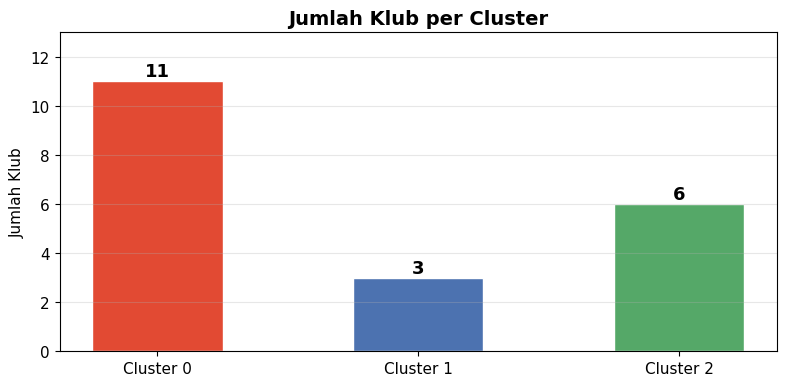

In [56]:
# --- Jumlah klub per cluster ---
cluster_colors = ["#E24A33", "#4C72B0", "#55A868", "#8172B2", "#C44E52",
                  "#CCB974", "#64B5CD"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f"Cluster {i}" for i in cluster_sizes.index],
    cluster_sizes.values,
    color=[cluster_colors[i] for i in cluster_sizes.index],
    edgecolor="white", width=0.5,
)
for bar, cnt in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(cnt), ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Jumlah Klub")
ax.set_title("Jumlah Klub per Cluster", fontsize=14, fontweight="bold")
ax.set_ylim(0, cluster_sizes.max() + 2)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---

## 11. Interpretasi Cluster

Analisis dilakukan dengan membandingkan centroid setiap cluster terhadap rata-rata liga untuk mengidentifikasi scoring yang relatif **tinggi** dan **rendah**.

In [57]:
# --- Z-score cluster profile vs liga ---
liga_mean = df_scores[score_cols].mean()
liga_std  = df_scores[score_cols].std()
cluster_zscore = (cluster_profile - liga_mean) / liga_std

print("⚽ Interpretasi Cluster — Berdasarkan 10 Style Scores")
print("=" * 80)

for cid in sorted(cluster_profile.index):
    clubs_in = df_result[df_result["cluster"] == cid]["club"].tolist()
    zs = cluster_zscore.loc[cid]
    profile = cluster_profile.loc[cid]

    high = zs[zs > 0.3].sort_values(ascending=False)
    low  = zs[zs < -0.3].sort_values(ascending=True)

    label_fn = lambda c: c.replace("_score", "").replace("_", " ").title()

    print(f"\n── Cluster {cid} ({len(clubs_in)} klub) ──")
    print(f"   Klub: {', '.join(clubs_in)}")

    if len(high) > 0:
        print(f"\n   🟢 HIGH:")
        for feat, z in high.items():
            print(f"      {label_fn(feat):<30s}  score={profile[feat]:.1f}  (z={z:+.2f})")

    if len(low) > 0:
        print(f"\n   🔴 LOW:")
        for feat, z in low.items():
            print(f"      {label_fn(feat):<30s}  score={profile[feat]:.1f}  (z={z:+.2f})")

    # Interpretasi otomatis
    print(f"\n   💡 Interpretation:")
    traits = []
    if zs.get("possession_score", 0) > 0.3 and zs.get("build_up_score", 0) > 0.3:
        traits.append("cenderung possession-oriented dengan build-up play yang sabar")
    elif zs.get("possession_score", 0) > 0.3:
        traits.append("cenderung menguasai bola")
    if zs.get("direct_play_score", 0) > 0.3 or zs.get("counter_attack_score", 0) > 0.3:
        traits.append("cenderung bermain langsung / counter-attack")
    if zs.get("pressing_score", 0) > 0.3:
        traits.append("intensitas pressing tinggi")
    if zs.get("defensive_solidity_score", 0) > 0.3:
        traits.append("pertahanan relatif solid")
    if zs.get("defensive_solidity_score", 0) < -0.3:
        traits.append("pertahanan relatif rentan")
    if zs.get("attacking_efficiency_score", 0) > 0.3:
        traits.append("efisiensi serangan tinggi")
    if zs.get("set_piece_score", 0) > 0.3:
        traits.append("ancaman bola mati signifikan")
    if zs.get("discipline_score", 0) > 0.3:
        traits.append("disiplin tinggi")
    if zs.get("discipline_score", 0) < -0.3:
        traits.append("cenderung agresif / kurang disiplin")
    if not traits:
        traits.append("profil mendekati rata-rata liga")

    for t in traits:
        print(f"      → Secara statistik, cluster ini {t}.")

print("\n" + "=" * 80)
print("\n⚠️  Interpretasi bersifat deskriptif berdasarkan Style Scores.")
print("   Kemiripan scoring tidak berarti gaya bermain identik.")

⚽ Interpretasi Cluster — Berdasarkan 10 Style Scores

── Cluster 0 (11 klub) ──
   Klub: Alaves, Athletic Bilbao, Espanyol, Getafe, Levante, Osasuna, Rayo Vallecano, Real Betis, Real Sociedad, Valencia, Villarreal

   🟢 HIGH:
      Direct Play                     score=50.3  (z=+0.63)
      Defensive Solidity              score=57.2  (z=+0.42)
      Set Piece                       score=53.4  (z=+0.34)
      Counter Attack                  score=44.5  (z=+0.30)

   🔴 LOW:
      Possession                      score=34.9  (z=-0.54)
      Build Up                        score=30.6  (z=-0.53)

   💡 Interpretation:
      → Secara statistik, cluster ini cenderung bermain langsung / counter-attack.
      → Secara statistik, cluster ini pertahanan relatif solid.
      → Secara statistik, cluster ini ancaman bola mati signifikan.

── Cluster 1 (3 klub) ──
   Klub: Atlético Madrid, Barcelona, Real Madrid

   🟢 HIGH:
      Chance Creation                 score=77.4  (z=+1.97)
      Build Up     

---

## 12. Visualisasi

### A. Heatmap Cluster Profile

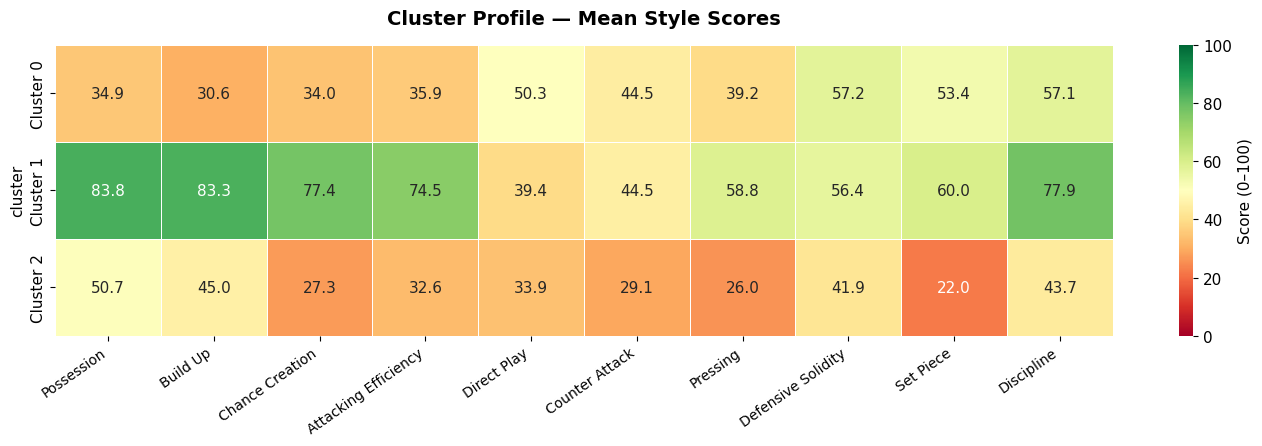

In [58]:
fig, ax = plt.subplots(figsize=(14, 3 + OPTIMAL_K * 0.8))

hm_labels = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]

sns.heatmap(
    cluster_profile,
    annot=True, fmt=".1f",
    cmap="RdYlGn", vmin=0, vmax=100,
    linewidths=0.5, square=False,
    xticklabels=hm_labels,
    yticklabels=[f"Cluster {i}" for i in cluster_profile.index],
    ax=ax,
    cbar_kws={"label": "Score (0–100)"},
)
ax.set_title("Cluster Profile — Mean Style Scores", fontsize=14, fontweight="bold", pad=15)
plt.xticks(fontsize=10, rotation=35, ha="right")
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### B. Radar Chart

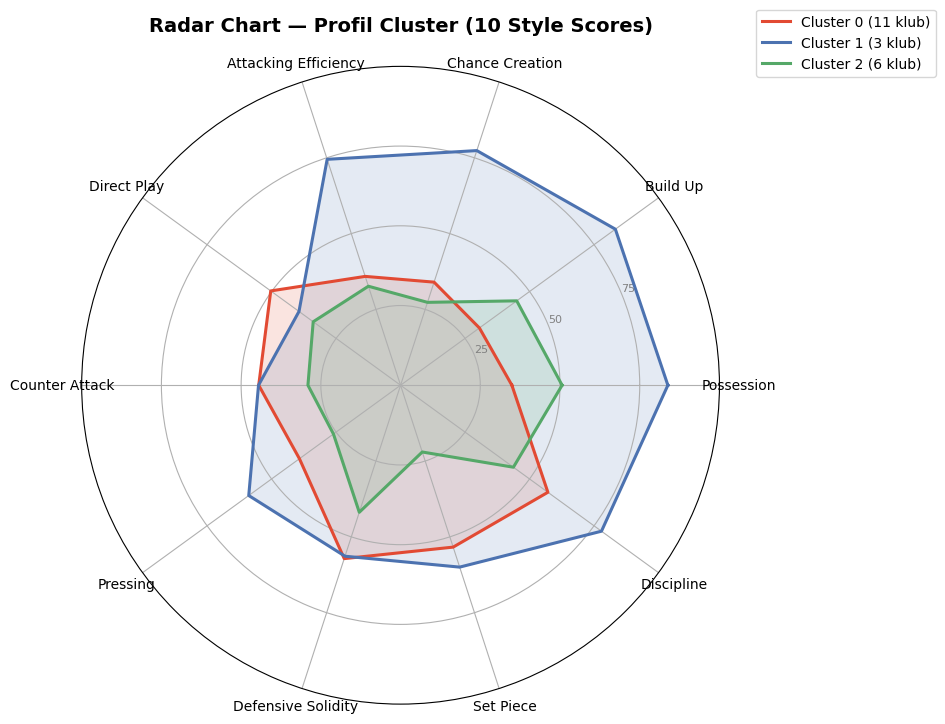

In [59]:
radar_labels = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]

num_vars = len(score_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# --- Overlay radar (semua cluster) ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cid in sorted(cluster_profile.index):
    vals = (cluster_profile.loc[cid] / 100).tolist()
    vals += vals[:1]
    ax.fill(angles, vals, alpha=0.15, color=cluster_colors[cid])
    ax.plot(angles, vals, linewidth=2.2, color=cluster_colors[cid],
            label=f"Cluster {cid} ({cluster_sizes[cid]} klub)")

ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(["25", "50", "75"], fontsize=8, color="gray")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_title("Radar Chart — Profil Cluster (10 Style Scores)",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2

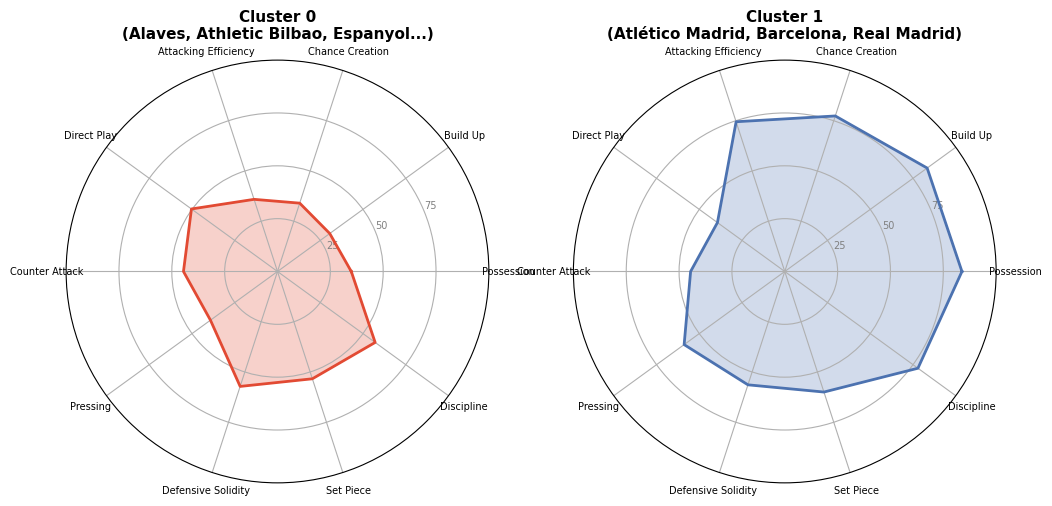

In [60]:
# --- Radar per cluster ---
n_clusters = OPTIMAL_K
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 6),
                         subplot_kw=dict(polar=True))
if n_clusters == 1:
    axes = [axes]

for idx, cid in enumerate(sorted(cluster_profile.index)):
    ax = axes[idx]
    vals = (cluster_profile.loc[cid] / 100).tolist()
    vals += vals[:1]
    ax.fill(angles, vals, alpha=0.25, color=cluster_colors[cid])
    ax.plot(angles, vals, linewidth=2, color=cluster_colors[cid])

    clubs_in = df_result[df_result["cluster"] == cid]["club"].tolist()
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=7, color="gray")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7)
    ax.set_title(f"Cluster {cid}\n({', '.join(clubs_in[:3])}{'...' if len(clubs_in) > 3 else ''})",
                 fontsize=11, fontweight="bold", pad=15)

plt.suptitle("Radar Chart per Cluster", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

### C. Heatmap Seluruh Klub

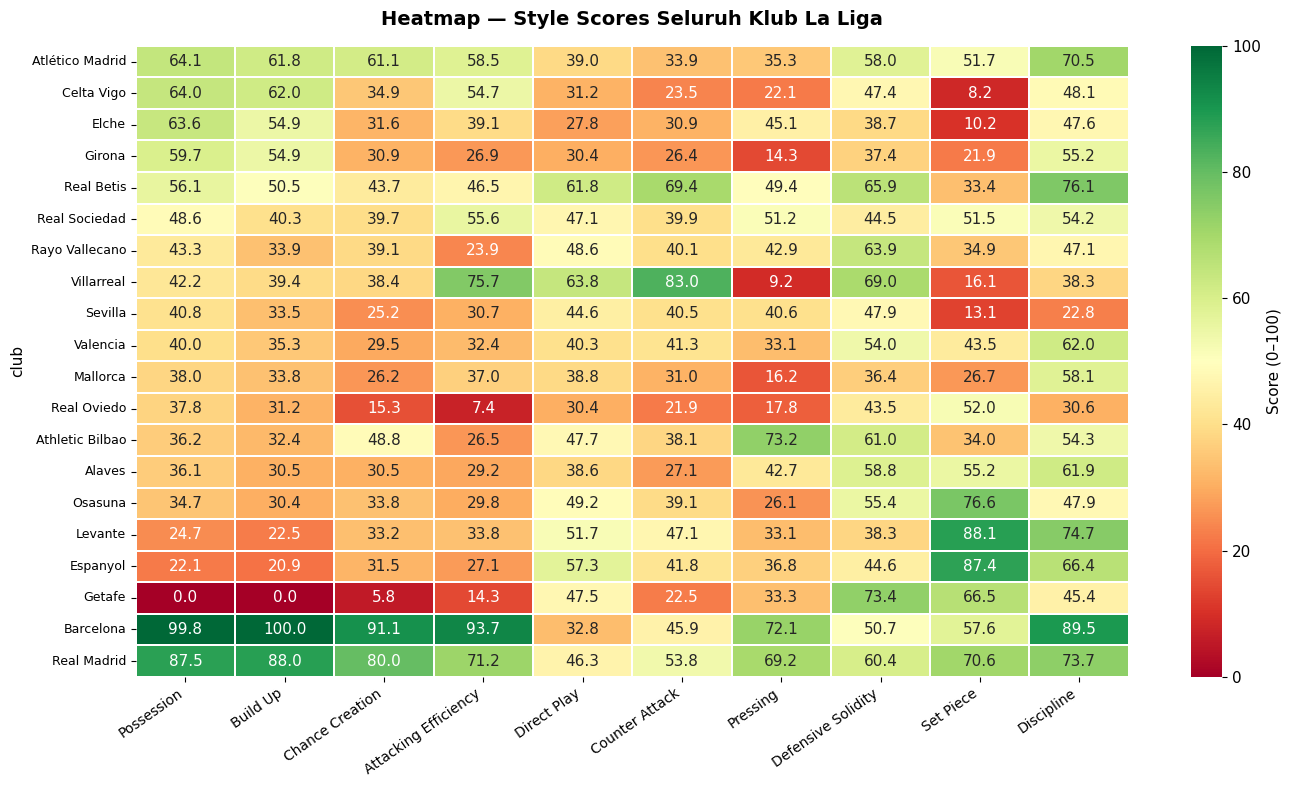

In [ ]:
# --- Heatmap seluruh klub ---
df_hm = df_clustered.set_index("club")[score_cols].copy()
df_hm["cluster"] = df_clustered.set_index("club")["cluster"]
df_hm = df_hm.sort_values(["cluster", df_hm.columns[0]], ascending=[True, False])
df_hm_display = df_hm.drop(columns="cluster")

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    df_hm_display,
    annot=True, fmt=".1f", cmap="RdYlGn",
    linewidths=0.3, vmin=0, vmax=100,
    xticklabels=hm_labels,
    ax=ax,
    cbar_kws={"label": "Score (0–100)"},
)
ax.set_title("Heatmap — Style Scores Seluruh Klub La Liga",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(fontsize=10, rotation=35, ha="right")
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### D. PCA Visualization

PCA digunakan **hanya untuk visualisasi** 2D — bukan sebagai input K-Means.

```
10 Style Scores → StandardScaler → K-Means  (pipeline utama)
10 Style Scores → StandardScaler → PCA(2D) → Scatter Plot  (visualisasi saja)
```

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100

print(f"📐 PCA (visualisasi saja):")
print(f"   PC1: {ev1:.1f}% variance")
print(f"   PC2: {ev2:.1f}% variance")
print(f"   Total: {ev1+ev2:.1f}%")

📐 PCA (visualisasi saja):
   PC1: 43.8% variance
   PC2: 23.9% variance
   Total: 67.7%


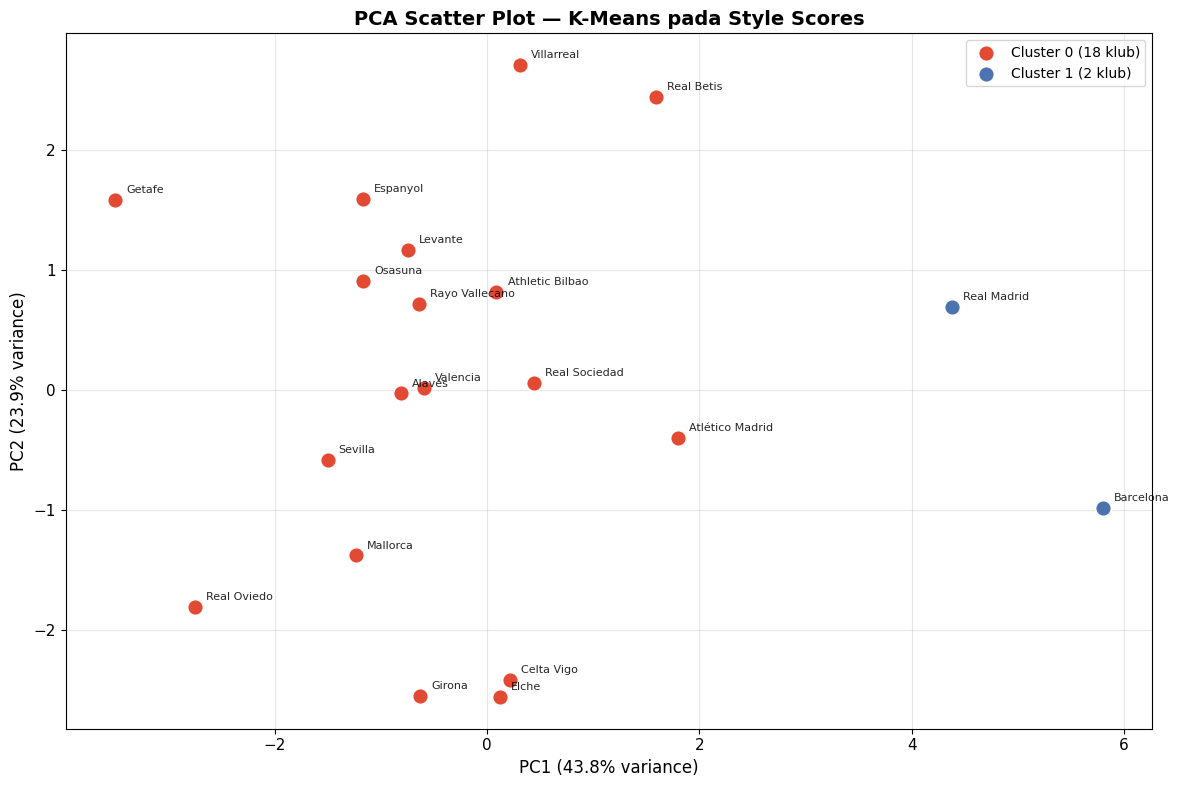

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

for cid in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == cid
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cid], s=130,
        label=f"Cluster {cid} ({cluster_sizes[cid]} klub)",
        edgecolors="white", linewidth=1.2, zorder=3,
    )

for i, club in enumerate(clubs):
    ax.annotate(club, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(8, 5),
                fontsize=8, alpha=0.85)

ax.set_xlabel(f"PC1 ({ev1:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({ev2:.1f}% variance)", fontsize=12)
ax.set_title("PCA Scatter Plot — K-Means pada Style Scores", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi Visualisasi

- **Heatmap profile** — menunjukkan "DNA" masing-masing cluster: warna hijau = scoring tinggi, merah = rendah.
- **Radar chart** — menunjukkan "shape" gaya bermain. Cluster yang lebih "lebar" di area tertentu menunjukkan dominasi dimensi tersebut.
- **PCA scatter** — memproyeksikan 10 dimensi ke 2D. Klub berdekatan memiliki profil Style Score yang serupa. Warna menunjukkan cluster assignment.

> PC1 dan PC2 bukan cluster. Mereka hanya representasi visual 2D dari data 10-dimensi.

---

## 13. Final Dataset

DataFrame akhir berisi seluruh Style Scores beserta cluster assignment.

In [ ]:
# --- DataFrame final ---
final_clustered_df = df_scores.copy()
final_clustered_df["cluster"] = cluster_labels
final_clustered_df = final_clustered_df.sort_values(
    ["cluster", "club"]
).reset_index(drop=True)

print("📋 Final Dataset:\n")
final_clustered_df

📋 Final Dataset:



,club,possession_score,build_up_score,chance_creation_score,attacking_efficiency_score,direct_play_score,counter_attack_score,pressing_score,defensive_solidity_score,set_piece_score,discipline_score,cluster
0,Alaves,36.07,30.53,30.49,29.19,38.65,27.11,42.75,58.82,55.21,61.87,0
1,Athletic Bilbao,36.19,32.40,48.81,26.54,47.68,38.08,73.22,61.00,34.02,54.28,0
2,Atlético Madrid,64.13,61.77,61.09,58.54,38.98,33.93,35.33,58.04,51.70,70.46,0
3,Celta Vigo,64.03,62.05,34.87,54.75,31.21,23.52,22.05,47.38,8.21,48.11,0
4,Elche,63.64,54.86,31.56,39.11,27.77,30.88,45.09,38.68,10.18,47.61,0
5,Espanyol,22.15,20.89,31.53,27.07,57.27,41.80,36.85,44.60,87.36,66.39,0
6,Getafe,0.00,0.00,5.79,14.26,47.46,22.48,33.31,73.37,66.52,45.42,0
7,Girona,59.66,54.86,30.88,26.94,30.45,26.44,14.34,37.45,21.89,55.24,0
8,Levante,24.73,22.52,33.25,33.77,51.66,47.15,33.14,38.26,88.06,74.70,0
9,Mallorca,37.97,33.78,26.22,36.99,38.78,31.05,16.19,36.38,26.67,58.14,0


In [ ]:
# --- Daftar klub per cluster ---
print("📋 Daftar Klub per Cluster")
print("=" * 50)

for cid in sorted(final_clustered_df["cluster"].unique()):
    clubs_in = final_clustered_df[
        final_clustered_df["cluster"] == cid
    ]["club"].tolist()
    print(f"\nCluster {cid} ({len(clubs_in)} klub):")
    for club in clubs_in:
        print(f"   • {club}")

print("\n" + "=" * 50)

📋 Daftar Klub per Cluster

Cluster 0 (18 klub):
   • Alaves
   • Athletic Bilbao
   • Atlético Madrid
   • Celta Vigo
   • Elche
   • Espanyol
   • Getafe
   • Girona
   • Levante
   • Mallorca
   • Osasuna
   • Rayo Vallecano
   • Real Betis
   • Real Oviedo
   • Real Sociedad
   • Sevilla
   • Valencia
   • Villarreal

Cluster 1 (2 klub):
   • Barcelona
   • Real Madrid



In [ ]:
# --- Simpan ---
output_dir = PROJECT_ROOT / "data" / "ml_ready"
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Cluster result
path_result = output_dir / "teams_kmeans_clustered.csv"
final_clustered_df.to_csv(path_result, index=False)
print(f"✅ Disimpan: {path_result.name} ({final_clustered_df.shape})")

# 2. Cluster profile
path_profile = output_dir / "cluster_profile_style_scores.csv"
cluster_profile_save = cluster_profile.copy()
cluster_profile_save["n_klub"] = cluster_sizes.values
cluster_profile_save.to_csv(path_profile)
print(f"✅ Disimpan: {path_profile.name} ({cluster_profile_save.shape})")

✅ Disimpan: teams_kmeans_clustered.csv ((20, 12))
✅ Disimpan: cluster_profile_style_scores.csv ((2, 11))


---

## 14. Final Summary

### End-to-End Summary

```
teams_statistics.csv (124 kolom, 20 klub)
    ↓
Feature Engineering (STYLE_CONFIG)
    • Primary indicators   → bobot 60%
    • Supporting indicators → bobot 40%
    • Inverse indicators   → dibalik sebelum agregasi
    • Min-Max normalization per indikator
    ↓
10 Style Scores (0–100)
    ↓
Validasi (no missing, no infinite, rentang valid)
    ↓
StandardScaler (mean=0, std=1)
    ↓
Pemilihan K (Elbow + Silhouette + Davies-Bouldin + Calinski-Harabasz)
    ↓
K-Means Clustering (random_state=42, n_init=20)
    ↓
Cluster Assignment + Profile + Interpretasi
```

### Ringkasan

| Item | Nilai |
|------|-------|
| Dataset | `teams_statistics.csv` (Gold Layer OBT) |
| Raw features | 124 kolom |
| Klub | 20 |
| Feature Engineering | 124 → 10 Style Scores |
| Primary/Supporting | 60% / 40% |
| Scaling | StandardScaler |
| K candidates | 2–6 |
| K final | *ditentukan dari evaluasi* |

### Output Files
- `data/ml_ready/teams_kmeans_clustered.csv` — club + 10 scoring + cluster
- `data/ml_ready/cluster_profile_style_scores.csv` — mean scoring per cluster

### Catatan Penting

1. Hasil K-Means menggambarkan **kecenderungan profil gaya bermain** berdasarkan 10 Style Scores — bukan label taktis yang absolut.
2. Style Scores dibentuk dari agregasi statistik mentah dengan bobot dan logika inverse yang telah ditentukan.
3. K-Means dilatih pada **10 Style Scores** (bukan 124 raw features).
4. PCA digunakan **hanya untuk visualisasi** 2D.
5. Setiap interpretasi cluster didasarkan pada kombinasi beberapa Style Scores, bukan satu dimensi saja.